# Keşifçi Veri Analizi (EDA) - Her Veri Seti İçin Ayrı Ayrı

Bu notebook, çalışma alanındaki her veri seti için ayrı ayrı Keşifçi Veri Analizi (EDA) adımlarını uygular.

In [1]:
# Gerekli kütüphaneleri import edelim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Görselleştirmeler için ayarlar
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

## EDA for malatya_gunluk_su_tuketimi_20yil.csv

In [2]:
# Veri setini yükleyelim
df_su = pd.read_csv('malatya_gunluk_su_tuketimi_20yil.csv')
print("Veri seti başarıyla yüklendi.")
print(f"Veri seti boyutu: {df_su.shape}")

Veri seti başarıyla yüklendi.
Veri seti boyutu: (7305, 4)


In [3]:
# Veri setinin yapısını inceleyelim
print("İlk 5 satır:")
print(df_su.head())
print("\nVeri seti bilgileri:")
print(df_su.info())
print(f"\nSütunlar: {list(df_su.columns)}")
print(f"Satır sayısı: {df_su.shape[0]}, Sütun sayısı: {df_su.shape[1]}")

İlk 5 satır:
        Tarih  Ort_Sicaklik  Hafta_Sonu  Su_Tuketimi_m3
0  2004-01-01          -1.7           0           93910
1  2004-01-02          -1.2           0           96421
2  2004-01-03          -5.7           1          102581
3  2004-01-04           0.9           1          103912
4  2004-01-05          -3.6           0           95013

Veri seti bilgileri:
<class 'pandas.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tarih           7305 non-null   str    
 1   Ort_Sicaklik    7305 non-null   float64
 2   Hafta_Sonu      7305 non-null   int64  
 3   Su_Tuketimi_m3  7305 non-null   int64  
dtypes: float64(1), int64(2), str(1)
memory usage: 228.4 KB
None

Sütunlar: ['Tarih', 'Ort_Sicaklik', 'Hafta_Sonu', 'Su_Tuketimi_m3']
Satır sayısı: 7305, Sütun sayısı: 4


In [4]:
# Eksik değerleri kontrol edelim
print("Eksik değer sayısı her sütunda:")
print(df_su.isnull().sum())
print(f"\nToplam eksik değer sayısı: {df_su.isnull().sum().sum()}")
print(f"Eksik değer yüzdesi: {df_su.isnull().sum().sum() / df_su.size * 100:.2f}%")

Eksik değer sayısı her sütunda:
Tarih             0
Ort_Sicaklik      0
Hafta_Sonu        0
Su_Tuketimi_m3    0
dtype: int64

Toplam eksik değer sayısı: 0
Eksik değer yüzdesi: 0.00%


In [5]:
# Sayısal özelliklerin özet istatistikleri
numerical_cols = df_su.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    print("Sayısal sütunlar için özet istatistikler:")
    print(df_su[numerical_cols].describe())
else:
    print("Sayısal sütun bulunamadı.")

Sayısal sütunlar için özet istatistikler:
       Ort_Sicaklik   Hafta_Sonu  Su_Tuketimi_m3
count   7305.000000  7305.000000     7305.000000
mean      15.011253     0.285832   151709.847228
std       11.687267     0.451841    25666.587529
min      -10.100000     0.000000    89671.000000
25%        4.400000     0.000000   133304.000000
50%       15.100000     0.000000   151396.000000
75%       25.900000     1.000000   170389.000000
max       39.500000     1.000000   217373.000000


In [6]:
# Kategorik özelliklerin analizi
categorical_cols = df_su.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    for col in categorical_cols:
        print(f"\n{col} sütunu için benzersiz değerler:")
        print(df_su[col].value_counts())
        print(f"Benzersiz değer sayısı: {df_su[col].nunique()}")
else:
    print("Kategorik sütun bulunamadı.")


Tarih sütunu için benzersiz değerler:
Tarih
2004-01-01    1
2004-01-02    1
2004-01-03    1
2004-01-04    1
2004-01-05    1
             ..
2023-12-27    1
2023-12-28    1
2023-12-29    1
2023-12-30    1
2023-12-31    1
Name: count, Length: 7305, dtype: int64
Benzersiz değer sayısı: 7305


C:\Users\CASPER\AppData\Local\Temp\ipykernel_17384\131869122.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_su.select_dtypes(include=['object']).columns


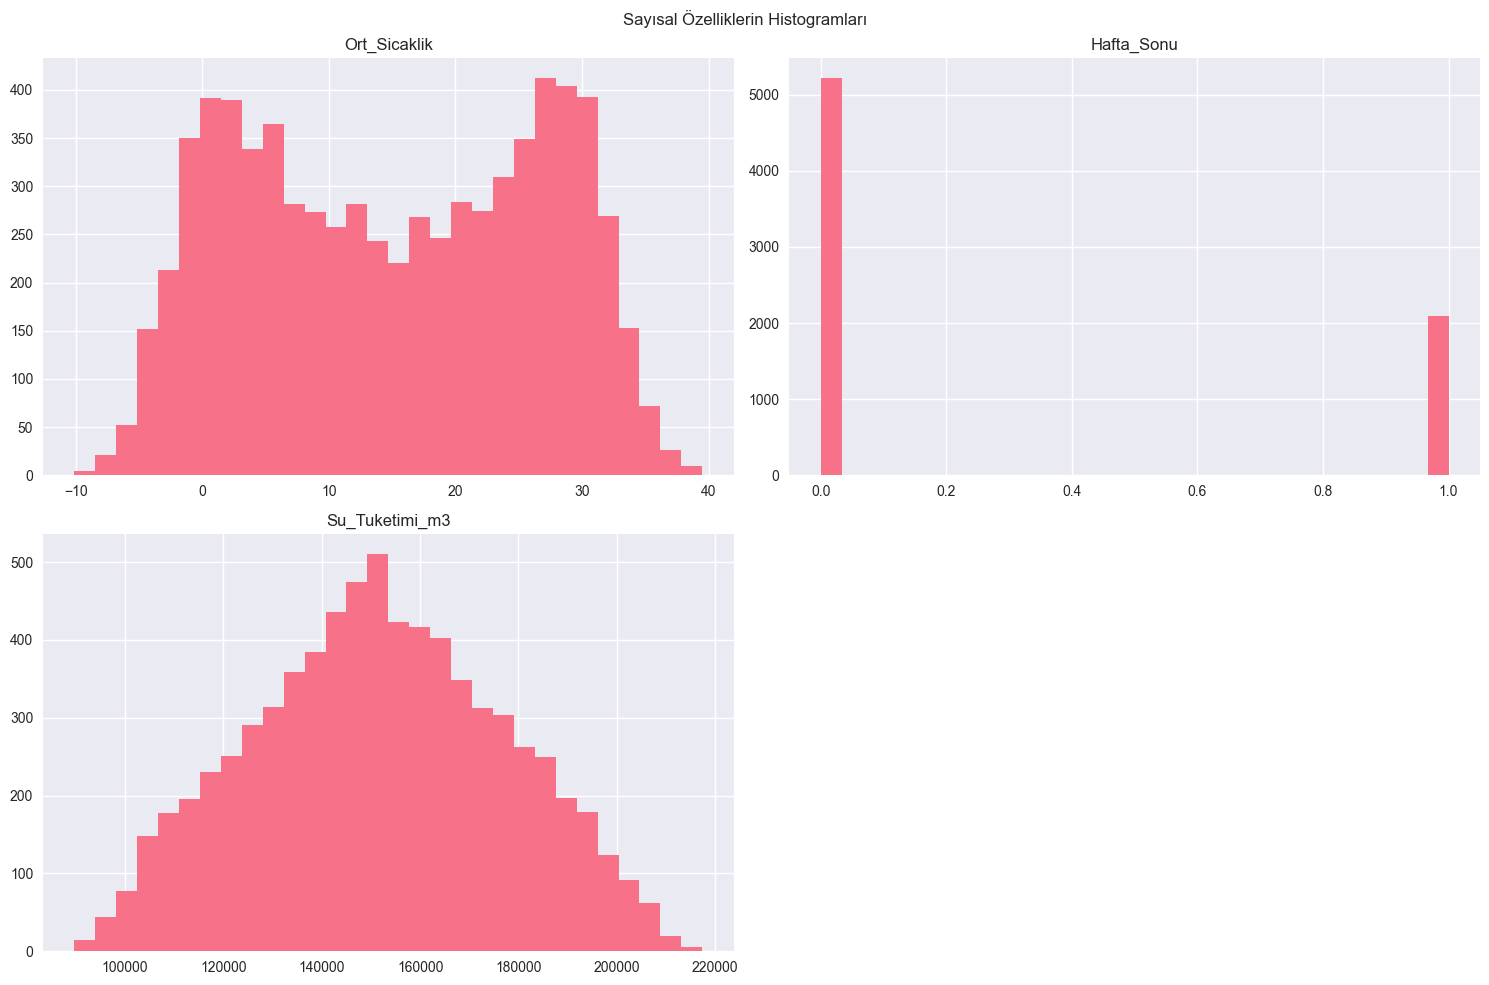

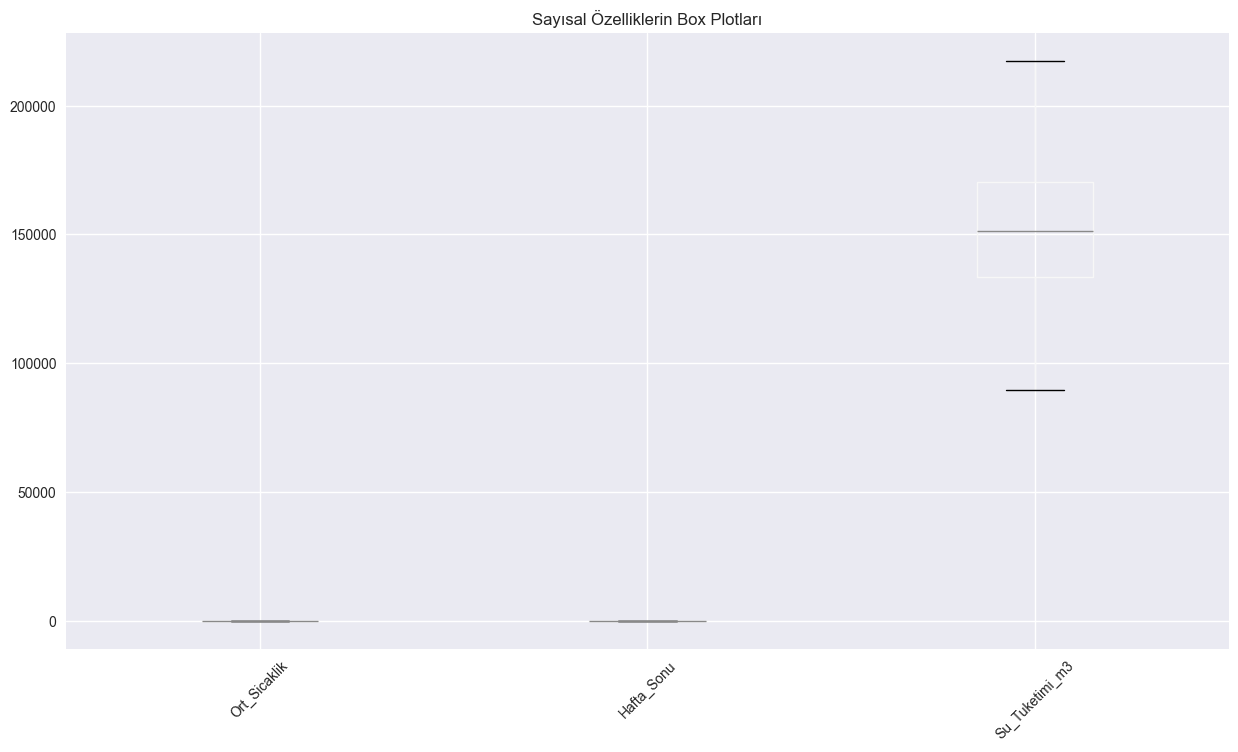

In [7]:
# Dağılımları görselleştirelim
if len(numerical_cols) > 0:
    df_su[numerical_cols].hist(bins=30, figsize=(15, 10))
    plt.suptitle('Sayısal Özelliklerin Histogramları')
    plt.tight_layout()
    plt.show()
    
    # Box plotlar
    plt.figure(figsize=(15, 8))
    df_su[numerical_cols].boxplot()
    plt.title('Sayısal Özelliklerin Box Plotları')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Görselleştirme için sayısal sütun bulunamadı.")

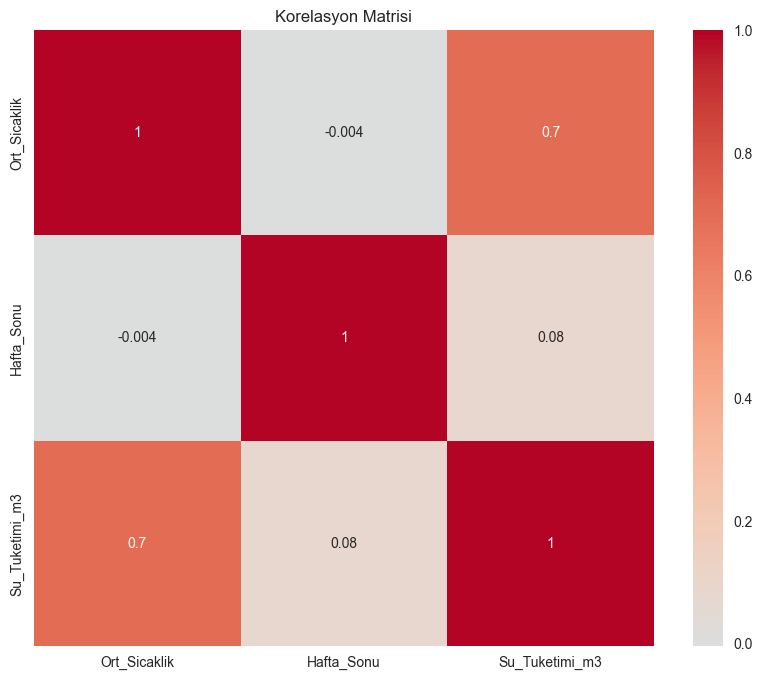

Korelasyon matrisinin sayısal değerleri:
                Ort_Sicaklik  Hafta_Sonu  Su_Tuketimi_m3
Ort_Sicaklik        1.000000   -0.003961        0.699404
Hafta_Sonu         -0.003961    1.000000        0.080024
Su_Tuketimi_m3      0.699404    0.080024        1.000000


In [8]:
# Korelasyon analizi
if len(numerical_cols) > 1:
    corr_matrix = df_su[numerical_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Korelasyon Matrisi')
    plt.show()
    
    print("Korelasyon matrisinin sayısal değerleri:")
    print(corr_matrix)
else:
    print("Korelasyon analizi için yeterli sayısal sütun bulunamadı.")

In [9]:
# Aykırı değer tespiti (IQR yöntemi)
if len(numerical_cols) > 0:
    for col in numerical_cols:
        Q1 = df_su[col].quantile(0.25)
        Q3 = df_su[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df_su[(df_su[col] < lower_bound) | (df_su[col] > upper_bound)]
        print(f"{col} sütununda aykırı değer sayısı: {len(outliers)}")
        if len(outliers) > 0:
            print(f"Aykırı değerler: {outliers[col].values}")
else:
    print("Aykırı değer tespiti için sayısal sütun bulunamadı.")

Ort_Sicaklik sütununda aykırı değer sayısı: 0
Hafta_Sonu sütununda aykırı değer sayısı: 0
Su_Tuketimi_m3 sütununda aykırı değer sayısı: 0


In [10]:
# Temel veri temizliği
print("Temizlik öncesi:")
print(f"Satır sayısı: {df_su.shape[0]}")
print(f"Duplike satır sayısı: {df_su.duplicated().sum()}")

# Duplike satırları kaldır
df_su_clean = df_su.drop_duplicates()

# Eksik değerleri doldur (ortalama ile sayısal sütunlar için)
for col in numerical_cols:
    if df_su_clean[col].isnull().sum() > 0:
        mean_val = df_su_clean[col].mean()
        df_su_clean[col].fillna(mean_val, inplace=True)
        print(f"{col} sütunundaki eksik değerler ortalama ({mean_val:.2f}) ile dolduruldu.")

print("\nTemizlik sonrası:")
print(f"Satır sayısı: {df_su_clean.shape[0]}")
print(f"Kalan eksik değer sayısı: {df_su_clean.isnull().sum().sum()}")

Temizlik öncesi:
Satır sayısı: 7305
Duplike satır sayısı: 0

Temizlik sonrası:
Satır sayısı: 7305
Kalan eksik değer sayısı: 0


## EDA for malatya_gunluk_yagis_20yil.csv

In [11]:
# Veri setini yükleyelim
df_yagis = pd.read_csv('malatya_gunluk_yagis_20yil.csv')
print("Veri seti başarıyla yüklendi.")
print(f"Veri seti boyutu: {df_yagis.shape}")

Veri seti başarıyla yüklendi.
Veri seti boyutu: (7305, 5)


In [12]:
# Veri setinin yapısını inceleyelim
print("İlk 5 satır:")
print(df_yagis.head())
print("\nVeri seti bilgileri:")
print(df_yagis.info())
print(f"\nSütunlar: {list(df_yagis.columns)}")
print(f"Satır sayısı: {df_yagis.shape[0]}, Sütun sayısı: {df_yagis.shape[1]}")

İlk 5 satır:
        Tarih  Karakaya_Yagis_mm  Surgu_Yagis_mm  Sultansuyu_Yagis_mm  \
0  2004-01-01                0.0             0.0                  0.0   
1  2004-01-02                0.0             0.0                  0.0   
2  2004-01-03                0.0             0.0                  0.0   
3  2004-01-04                0.0             0.0                  0.0   
4  2004-01-05                0.7             1.2                  1.0   

   Genel_Ortalama_mm  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                1.0  

Veri seti bilgileri:
<class 'pandas.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tarih                7305 non-null   str    
 1   Karakaya_Yagis_mm    7305 non-null   float64
 2   Surgu_Yagis_mm       7305 non-null   float64
 3   Sultansuyu_Yagis_mm  7305 non-null   f

In [13]:
# Eksik değerleri kontrol edelim
print("Eksik değer sayısı her sütunda:")
print(df_yagis.isnull().sum())
print(f"\nToplam eksik değer sayısı: {df_yagis.isnull().sum().sum()}")
print(f"Eksik değer yüzdesi: {df_yagis.isnull().sum().sum() / df_yagis.size * 100:.2f}%")

Eksik değer sayısı her sütunda:
Tarih                  0
Karakaya_Yagis_mm      0
Surgu_Yagis_mm         0
Sultansuyu_Yagis_mm    0
Genel_Ortalama_mm      0
dtype: int64

Toplam eksik değer sayısı: 0
Eksik değer yüzdesi: 0.00%


In [14]:
# EDA fonksiyonu tanımlayalım
def perform_eda(df, name):
    print(f"\n=== EDA for {name} ===")
    
    # Structure
    print("İlk 5 satır:")
    print(df.head())
    print(f"\nBoyut: {df.shape}")
    print(f"Sütunlar: {list(df.columns)}")
    print(f"Veri tipleri:\n{df.dtypes}")
    
    # Missing values
    missing = df.isnull().sum()
    print(f"\nEksik değerler:\n{missing}")
    print(f"Toplam eksik: {missing.sum()}")
    
    # Numerical summary
    num_cols = df.select_dtypes(include=[np.number]).columns
    if len(num_cols) > 0:
        print(f"\nSayısal sütunlar özeti:\n{df[num_cols].describe()}")
    
    # Categorical summary
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        for col in cat_cols:
            print(f"\n{col} benzersiz değerler: {df[col].nunique()}")
    
    # Visualizations
    if len(num_cols) > 0:
        df[num_cols].hist(bins=20, figsize=(12, 8))
        plt.suptitle(f'{name} - Histogramlar')
        plt.show()
        
        if len(num_cols) > 1:
            corr = df[num_cols].corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm')
            plt.title(f'{name} - Korelasyon')
            plt.show()
    
    # Outliers
    if len(num_cols) > 0:
        for col in num_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
            print(f"{col} aykırı değer sayısı: {outliers}")
    
    # Basic cleaning
    df_clean = df.drop_duplicates()
    for col in num_cols:
        if df_clean[col].isnull().any():
            df_clean[col].fillna(df_clean[col].mean(), inplace=True)
    print(f"Temizlik sonrası boyut: {df_clean.shape}")
    return df_clean


=== EDA for malatya_gunluk_yagis_20yil.csv ===
İlk 5 satır:
        Tarih  Karakaya_Yagis_mm  Surgu_Yagis_mm  Sultansuyu_Yagis_mm  \
0  2004-01-01                0.0             0.0                  0.0   
1  2004-01-02                0.0             0.0                  0.0   
2  2004-01-03                0.0             0.0                  0.0   
3  2004-01-04                0.0             0.0                  0.0   
4  2004-01-05                0.7             1.2                  1.0   

   Genel_Ortalama_mm  
0                0.0  
1                0.0  
2                0.0  
3                0.0  
4                1.0  

Boyut: (7305, 5)
Sütunlar: ['Tarih', 'Karakaya_Yagis_mm', 'Surgu_Yagis_mm', 'Sultansuyu_Yagis_mm', 'Genel_Ortalama_mm']
Veri tipleri:
Tarih                      str
Karakaya_Yagis_mm      float64
Surgu_Yagis_mm         float64
Sultansuyu_Yagis_mm    float64
Genel_Ortalama_mm      float64
dtype: object

Eksik değerler:
Tarih                  0
Karakaya_Yagis_m

C:\Users\CASPER\AppData\Local\Temp\ipykernel_17384\3378418452.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


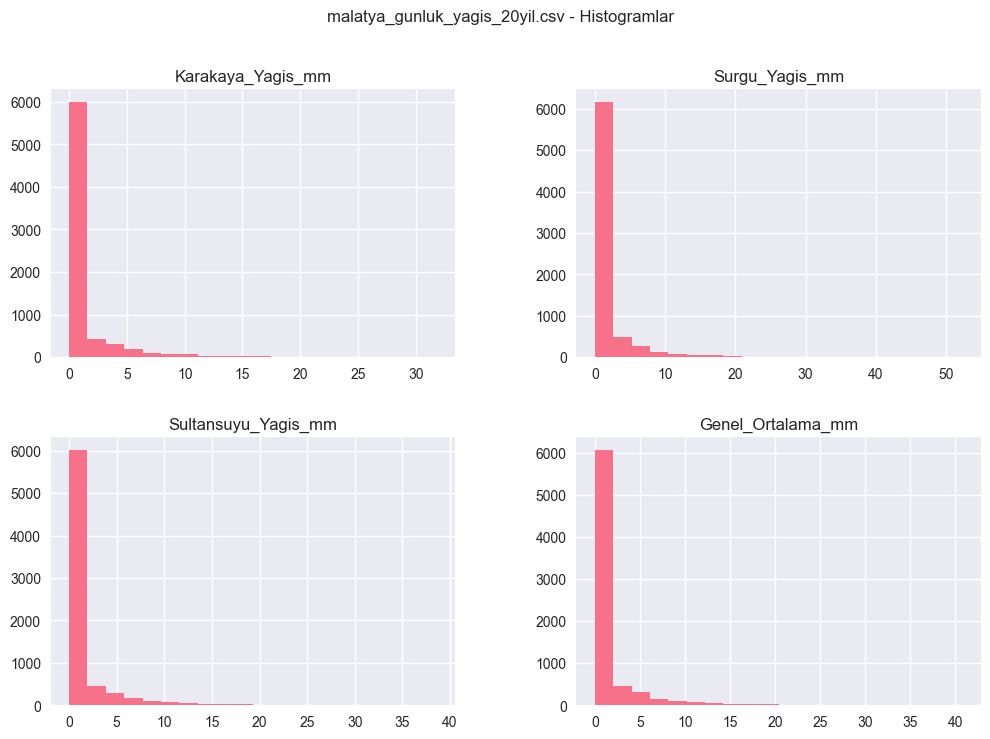

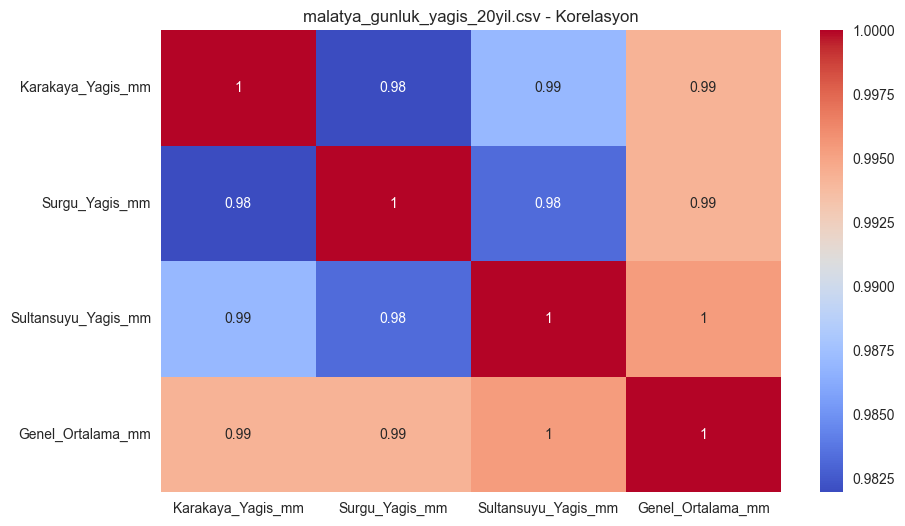

Karakaya_Yagis_mm aykırı değer sayısı: 1681
Surgu_Yagis_mm aykırı değer sayısı: 1637
Sultansuyu_Yagis_mm aykırı değer sayısı: 1636
Genel_Ortalama_mm aykırı değer sayısı: 1628
Temizlik sonrası boyut: (7305, 5)


In [15]:
# İkinci veri seti
df_yagis = pd.read_csv('malatya_gunluk_yagis_20yil.csv')
df_yagis_clean = perform_eda(df_yagis, 'malatya_gunluk_yagis_20yil.csv')


=== EDA for malatya_iklim_senaryosu_2024_2053.csv ===
İlk 5 satır:
        Tarih   Yil  Ay  Ort_Sicaklik  Toplam_Yagis  Karakaya_Doluluk  \
0  2024-01-01  2024   1           1.7          63.4              77.3   
1  2024-02-01  2024   2           4.1          66.7              67.6   
2  2024-03-01  2024   3           9.4          72.6              62.2   
3  2024-04-01  2024   4          13.3          52.4              49.3   
4  2024-05-01  2024   5          22.2          44.4              45.3   

   Surgu_Doluluk  Sultansuyu_Doluluk  Genel_Ortalama  
0           81.2                69.0            75.8  
1           68.1                58.3            64.7  
2           60.8                59.4            60.8  
3           52.0                51.8            51.0  
4           50.5                42.9            46.2  

Boyut: (360, 9)
Sütunlar: ['Tarih', 'Yil', 'Ay', 'Ort_Sicaklik', 'Toplam_Yagis', 'Karakaya_Doluluk', 'Surgu_Doluluk', 'Sultansuyu_Doluluk', 'Genel_Ortalama']
Veri

C:\Users\CASPER\AppData\Local\Temp\ipykernel_17384\3378418452.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


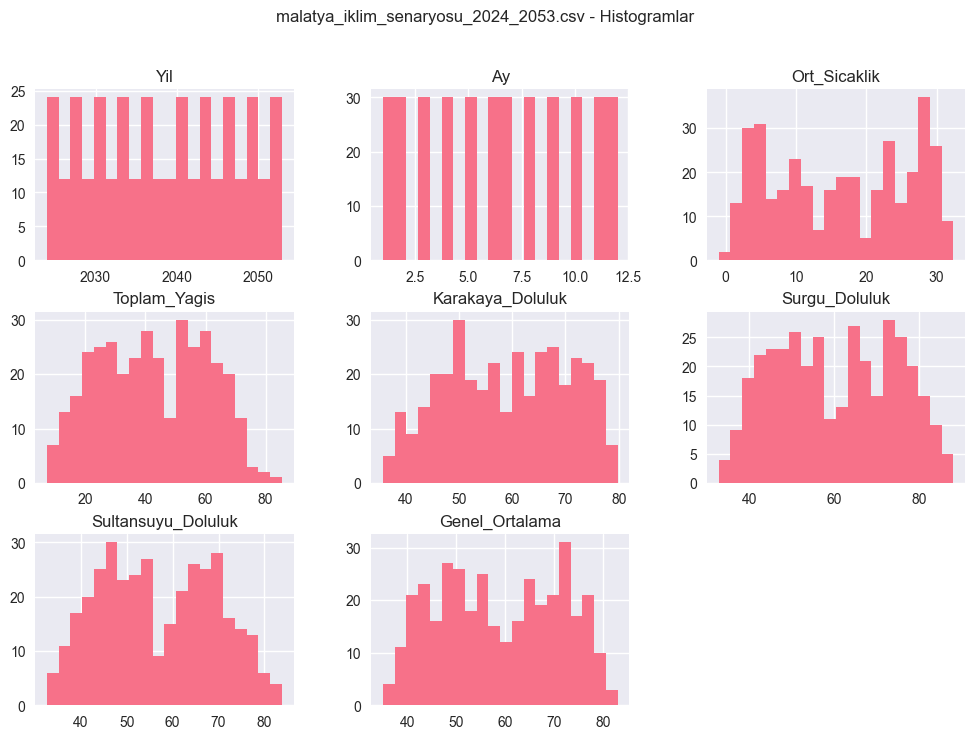

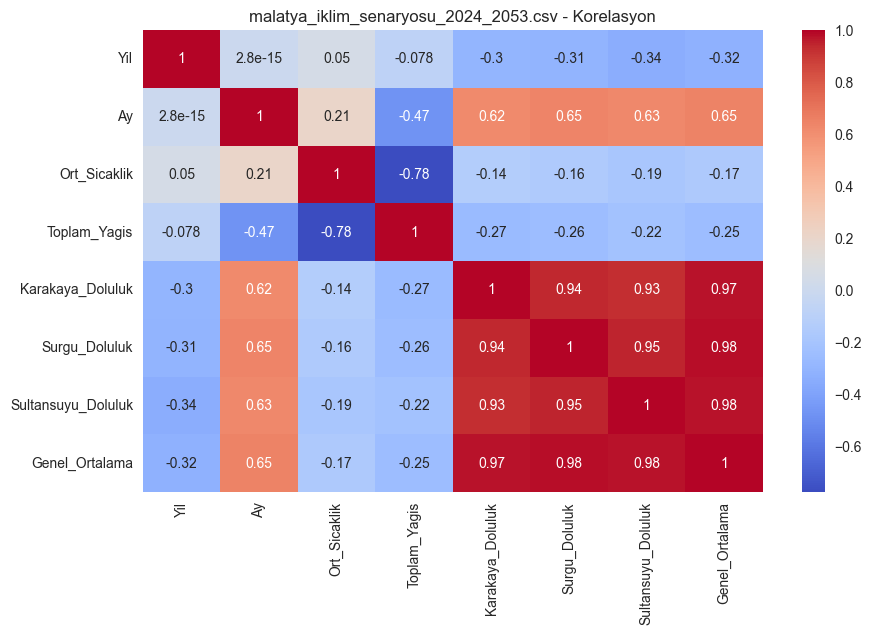

Yil aykırı değer sayısı: 0
Ay aykırı değer sayısı: 0
Ort_Sicaklik aykırı değer sayısı: 0
Toplam_Yagis aykırı değer sayısı: 0
Karakaya_Doluluk aykırı değer sayısı: 0
Surgu_Doluluk aykırı değer sayısı: 0
Sultansuyu_Doluluk aykırı değer sayısı: 0
Genel_Ortalama aykırı değer sayısı: 0
Temizlik sonrası boyut: (360, 9)


In [16]:
# Üçüncü veri seti
df_iklim = pd.read_csv('malatya_iklim_senaryosu_2024_2053.csv')
df_iklim_clean = perform_eda(df_iklim, 'malatya_iklim_senaryosu_2024_2053.csv')


=== EDA for malatya_nufus_projeksiyonu_2024_2053.csv ===
İlk 5 satır:
    Yil  Toplam_Nufus  Kentsel_Nufus  Kirsal_Nufus  Ortalama_Hane_Buyuklugu  \
0  2024        763500         628614        134886                     3.57   
1  2025        777243         642520        134723                     3.55   
2  2026        791233         656723        134510                     3.52   
3  2027        805475         671229        134246                     3.49   
4  2028        819974         686045        133929                     3.47   

   Toplam_Hane_Sayisi  
0              213666  
1              219147  
2              224782  
3              230575  
4              236531  

Boyut: (30, 6)
Sütunlar: ['Yil', 'Toplam_Nufus', 'Kentsel_Nufus', 'Kirsal_Nufus', 'Ortalama_Hane_Buyuklugu', 'Toplam_Hane_Sayisi']
Veri tipleri:
Yil                          int64
Toplam_Nufus                 int64
Kentsel_Nufus                int64
Kirsal_Nufus                 int64
Ortalama_Hane_Buyuklugu 

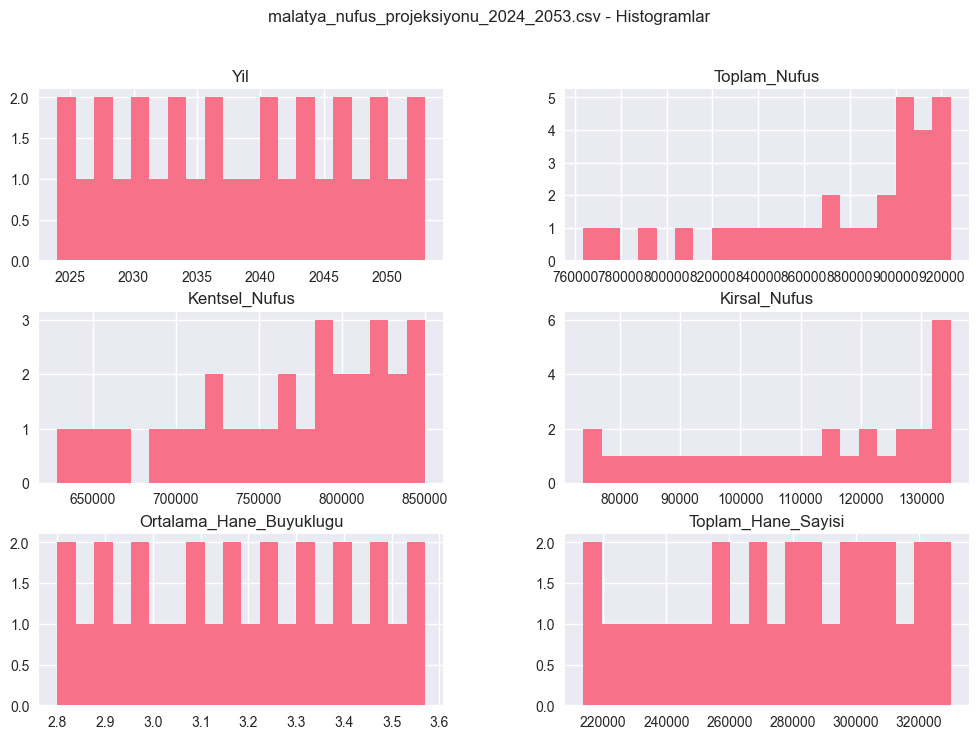

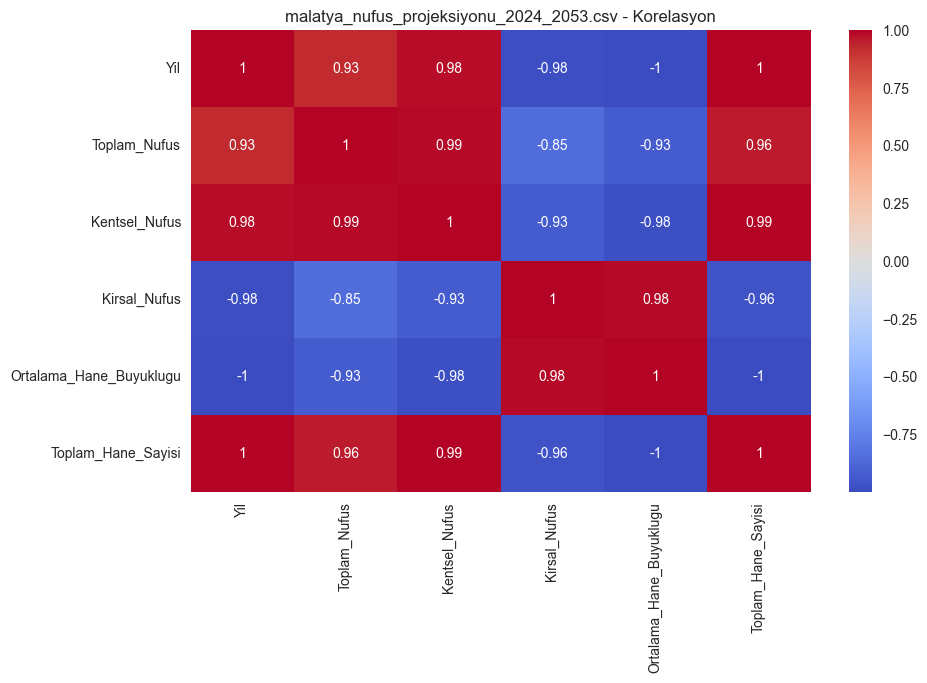

Yil aykırı değer sayısı: 0
Toplam_Nufus aykırı değer sayısı: 0
Kentsel_Nufus aykırı değer sayısı: 0
Kirsal_Nufus aykırı değer sayısı: 0
Ortalama_Hane_Buyuklugu aykırı değer sayısı: 0
Toplam_Hane_Sayisi aykırı değer sayısı: 0
Temizlik sonrası boyut: (30, 6)


In [17]:
# Dördüncü veri seti
df_nufus = pd.read_csv('malatya_nufus_projeksiyonu_2024_2053.csv')
df_nufus_clean = perform_eda(df_nufus, 'malatya_nufus_projeksiyonu_2024_2053.csv')


=== EDA for malatya_kayip_kacak_20yil.csv ===
İlk 5 satır:
        Tarih     Bolge_Tipi   Nufus  Altyapi_Yasi_Yil  Sebeke_Uzunlugu_km  \
0  2004-01-01    Eski_Merkez  280000                18                 800   
1  2004-01-01  Hizli_Buyuyen   80000                 0                 400   
2  2004-01-01  Yeni_Yerlesim    5000                10                  30   
3  2004-02-01    Eski_Merkez  280000                18                 800   
4  2004-02-01  Hizli_Buyuyen   80000                 0                 400   

   Ort_Basinc_Bar  Deprem_Hasar_Katsayisi  Net_Tuketilen_Su_m3  \
0             3.8                     1.0              1344000   
1             4.0                     1.0               384000   
2             3.2                     1.0                24000   
3             3.8                     1.0              1344000   
4             4.0                     1.0               384000   

   Sisteme_Verilen_Su_m3  Kayip_Kacak_Orani_%  
0                2174526  

C:\Users\CASPER\AppData\Local\Temp\ipykernel_17384\3378418452.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


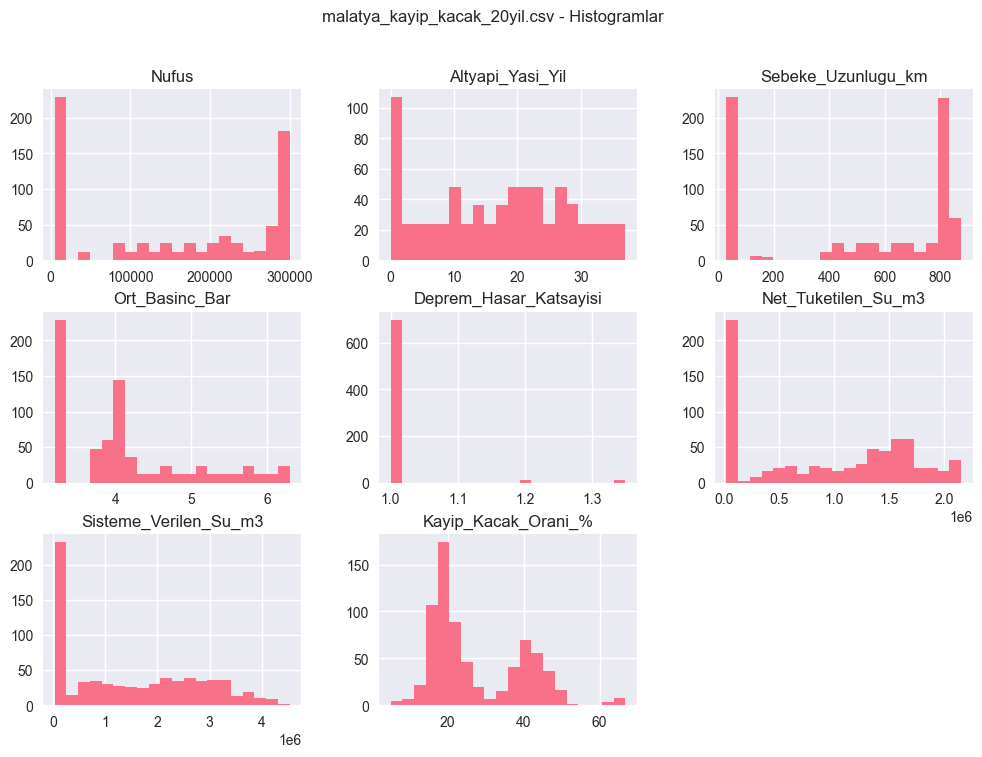

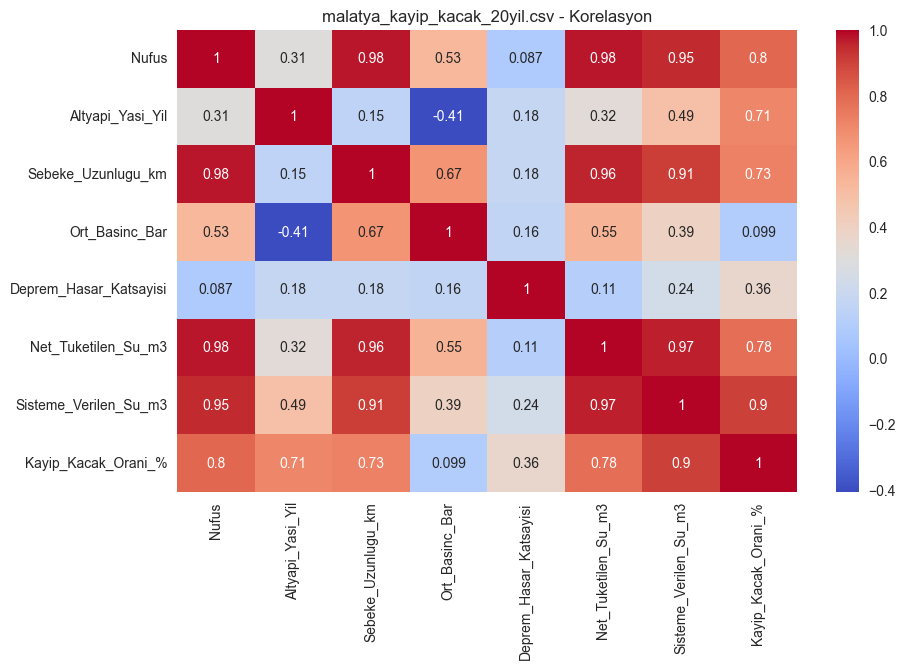

Nufus aykırı değer sayısı: 0
Altyapi_Yasi_Yil aykırı değer sayısı: 0
Sebeke_Uzunlugu_km aykırı değer sayısı: 0
Ort_Basinc_Bar aykırı değer sayısı: 0
Deprem_Hasar_Katsayisi aykırı değer sayısı: 22
Net_Tuketilen_Su_m3 aykırı değer sayısı: 0
Sisteme_Verilen_Su_m3 aykırı değer sayısı: 0
Kayip_Kacak_Orani_% aykırı değer sayısı: 0
Temizlik sonrası boyut: (720, 10)


In [18]:
# Beşinci veri seti
df_kayip = pd.read_csv('malatya_kayip_kacak_20yil.csv')
df_kayip_clean = perform_eda(df_kayip, 'malatya_kayip_kacak_20yil.csv')


=== EDA for malatya_sektorel_tuketim_tarimli_20yil.csv ===
İlk 5 satır:
        Tarih  Toplam_Tuketim_m3  Hane_m3  Sanayi_m3  Tarim_m3  Diger_m3
0  2004-01-01            3552154  2483069     643528     73207    352350
1  2004-02-01            3475413  2427093     635453     70575    342292
2  2004-03-01            3450705  2428599     618248     68371    335487
3  2004-04-01            4583027  2247670     675596   1132871    526890
4  2004-05-01            4411748  2212805     655753   1071783    471407

Boyut: (240, 6)
Sütunlar: ['Tarih', 'Toplam_Tuketim_m3', 'Hane_m3', 'Sanayi_m3', 'Tarim_m3', 'Diger_m3']
Veri tipleri:
Tarih                  str
Toplam_Tuketim_m3    int64
Hane_m3              int64
Sanayi_m3            int64
Tarim_m3             int64
Diger_m3             int64
dtype: object

Eksik değerler:
Tarih                0
Toplam_Tuketim_m3    0
Hane_m3              0
Sanayi_m3            0
Tarim_m3             0
Diger_m3             0
dtype: int64
Toplam eksik: 0

Sayısal 

C:\Users\CASPER\AppData\Local\Temp\ipykernel_17384\3378418452.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


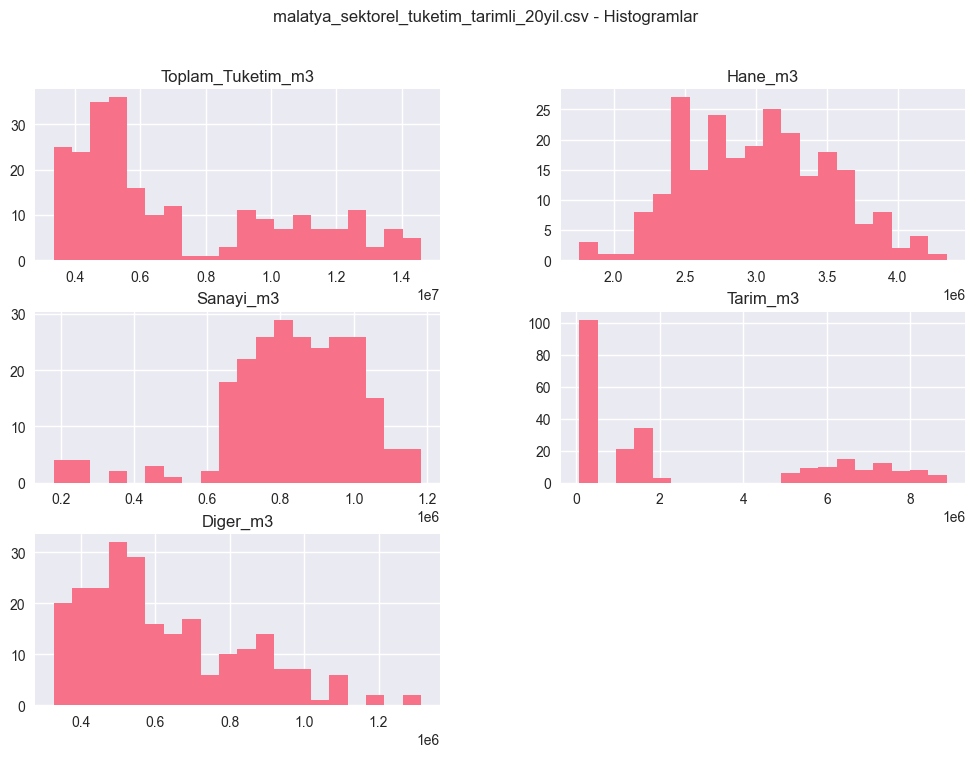

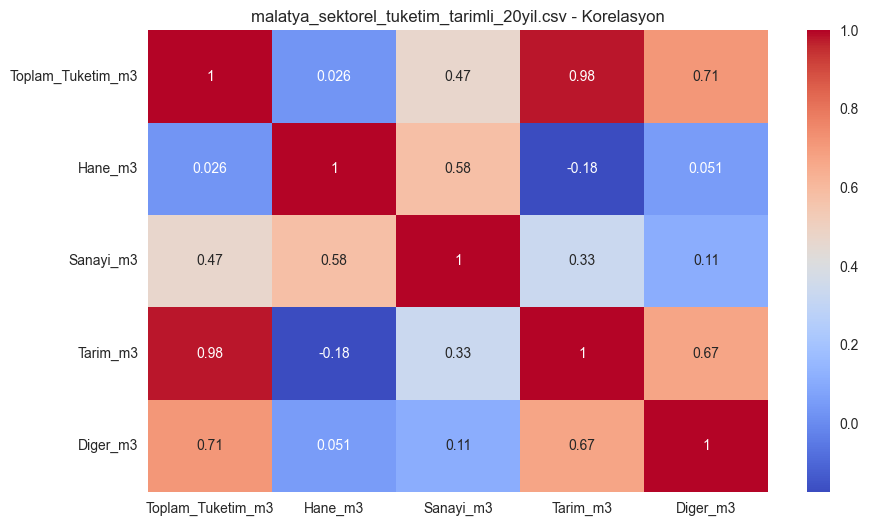

Toplam_Tuketim_m3 aykırı değer sayısı: 0
Hane_m3 aykırı değer sayısı: 0
Sanayi_m3 aykırı değer sayısı: 10
Tarim_m3 aykırı değer sayısı: 0
Diger_m3 aykırı değer sayısı: 2
Temizlik sonrası boyut: (240, 6)


In [19]:
# Altıncı veri seti
df_sektorel = pd.read_csv('malatya_sektorel_tuketim_tarimli_20yil.csv')
df_sektorel_clean = perform_eda(df_sektorel, 'malatya_sektorel_tuketim_tarimli_20yil.csv')

In [20]:
# Yedinci veri seti
df_sosyo = pd.read_csv('malatya_sosyoekonomik_20yil.csv')
df_sosyo_clean = perform_eda(df_sosyo, 'malatya_sosyoekonomik_20yil.csv')


=== EDA for malatya_sosyoekonomik_20yil.csv ===
İlk 5 satır:
  Yil,Su_Tarifesi_TL_m3,Kisi_Basi_Gelir_USD,Ziyaretci_Sayisi_Aylik_Ort
0                               2004,0.65,4200,18500                  
1                               2005,0.72,5000,19200                  
2                               2006,0.85,5500,20500                  
3                               2007,0.98,6200,21000                  
4                               2008,1.10,6800,22500                  

Boyut: (20, 1)
Sütunlar: ['Yil,Su_Tarifesi_TL_m3,Kisi_Basi_Gelir_USD,Ziyaretci_Sayisi_Aylik_Ort']
Veri tipleri:
Yil,Su_Tarifesi_TL_m3,Kisi_Basi_Gelir_USD,Ziyaretci_Sayisi_Aylik_Ort    str
dtype: object

Eksik değerler:
Yil,Su_Tarifesi_TL_m3,Kisi_Basi_Gelir_USD,Ziyaretci_Sayisi_Aylik_Ort    0
dtype: int64
Toplam eksik: 0

Yil,Su_Tarifesi_TL_m3,Kisi_Basi_Gelir_USD,Ziyaretci_Sayisi_Aylik_Ort benzersiz değerler: 20
Temizlik sonrası boyut: (20, 1)


C:\Users\CASPER\AppData\Local\Temp\ipykernel_17384\3378418452.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


In [21]:
# Sekizinci veri seti
df_genel = pd.read_csv('veri_seti.csv')
df_genel_clean = perform_eda(df_genel, 'veri_seti.csv')


=== EDA for veri_seti.csv ===
İlk 5 satır:
  Yil,Ay,Karakaya_Doluluk,Surgu_Doluluk,Sultansuyu_Doluluk,Genel_Ortalama,Ort_Sicaklik,Toplam_Yagis
0                2004,1,58.0,60.0,62.0,60.0,2.1,45.0                                               
1                2004,2,60.0,63.0,64.0,62.3,3.5,40.0                                               
2                2004,3,65.0,70.0,68.0,67.6,8.5,55.0                                               
3               2004,4,72.0,78.0,76.0,75.3,14.0,60.0                                               
4               2004,5,78.0,84.0,82.0,81.3,18.5,50.0                                               

Boyut: (240, 1)
Sütunlar: ['Yil,Ay,Karakaya_Doluluk,Surgu_Doluluk,Sultansuyu_Doluluk,Genel_Ortalama,Ort_Sicaklik,Toplam_Yagis']
Veri tipleri:
Yil,Ay,Karakaya_Doluluk,Surgu_Doluluk,Sultansuyu_Doluluk,Genel_Ortalama,Ort_Sicaklik,Toplam_Yagis    str
dtype: object

Eksik değerler:
Yil,Ay,Karakaya_Doluluk,Surgu_Doluluk,Sultansuyu_Doluluk,Genel_Ortalama,Ort_S

C:\Users\CASPER\AppData\Local\Temp\ipykernel_17384\3378418452.py:23: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns
